In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/raw/hcvdat0.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (615, 14)


,Unnamed: 0,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,1,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,2,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,3,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,4,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,5,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


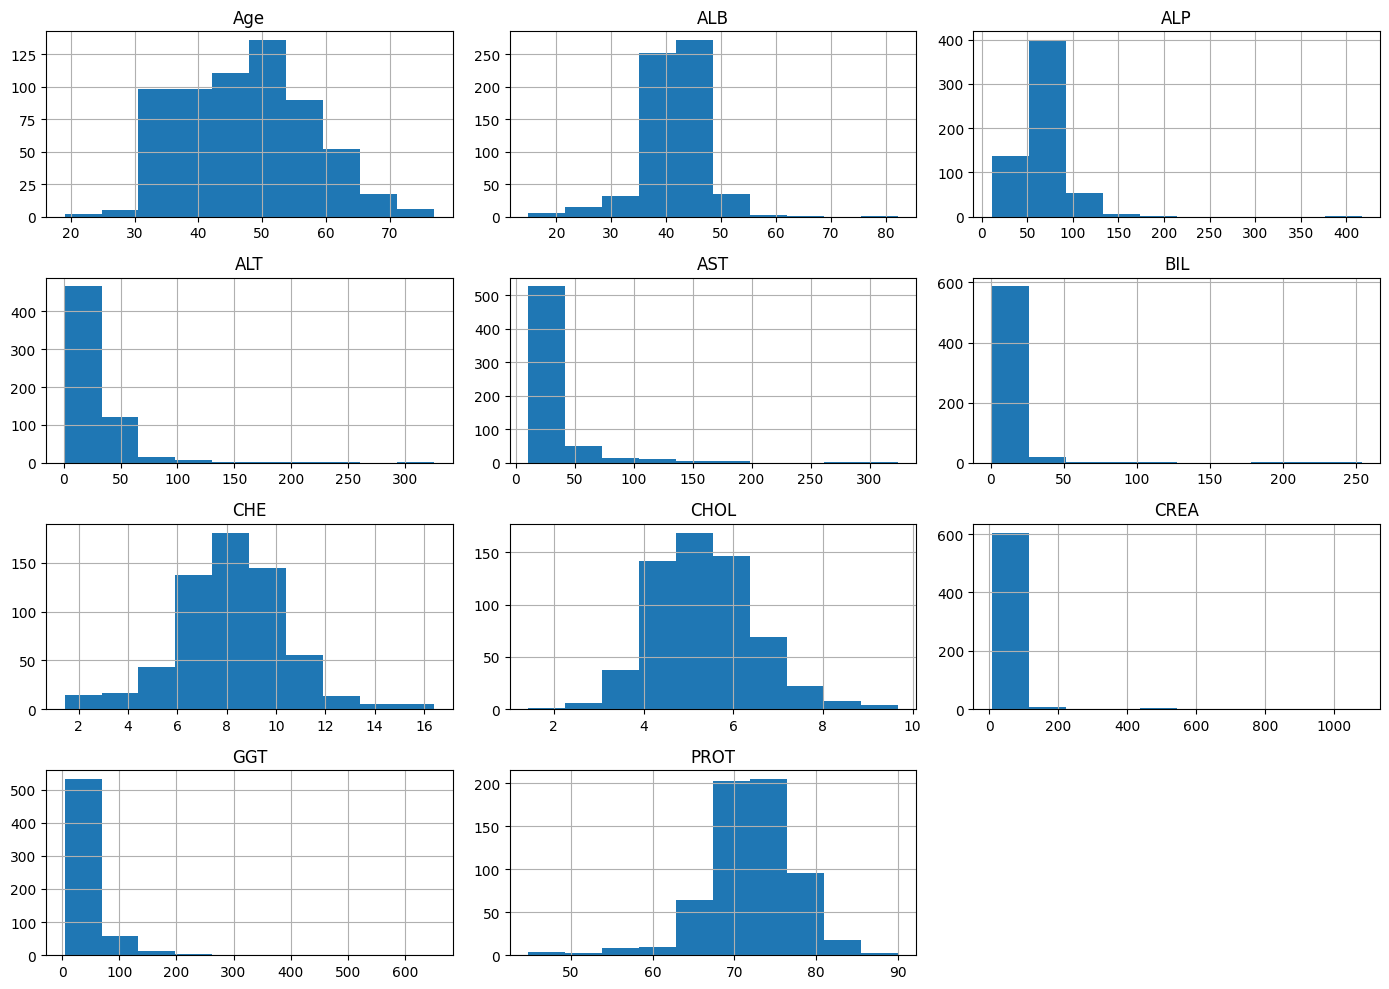

In [47]:
numerical_features = [
    "Age", "ALB", "ALP", "ALT", "AST",
    "BIL", "CHE", "CHOL", "CREA", "GGT", "PROT"
]

df[numerical_features].hist(figsize=(14, 10))

plt.tight_layout()
plt.show()

In [20]:
df.info()
df.describe()
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  615 non-null    int64  
 1   Category    615 non-null    object 
 2   Age         615 non-null    int64  
 3   Sex         615 non-null    object 
 4   ALB         614 non-null    float64
 5   ALP         597 non-null    float64
 6   ALT         614 non-null    float64
 7   AST         615 non-null    float64
 8   BIL         615 non-null    float64
 9   CHE         615 non-null    float64
 10  CHOL        605 non-null    float64
 11  CREA        615 non-null    float64
 12  GGT         615 non-null    float64
 13  PROT        614 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 67.4+ KB
['Unnamed: 0', 'Category', 'Age', 'Sex', 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'GGT', 'PROT']


In [21]:
missing = df.isnull().sum()

print(missing)

Unnamed: 0     0
Category       0
Age            0
Sex            0
ALB            1
ALP           18
ALT            1
AST            0
BIL            0
CHE            0
CHOL          10
CREA           0
GGT            0
PROT           1
dtype: int64


In [22]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [23]:
print(df["Category"].value_counts())

Category
0=Blood Donor             533
3=Cirrhosis                30
1=Hepatitis                24
2=Fibrosis                 21
0s=suspect Blood Donor      7
Name: count, dtype: int64


In [24]:
df[numerical_features].describe().T


,count,mean,std,min,25%,50%,75%,max
Age,615.0,47.408130,10.055105,19.00,39.000,47.00,54.000,77.00
ALB,614.0,41.620195,5.780629,14.90,38.800,41.95,45.200,82.20
ALP,597.0,68.283920,26.028315,11.30,52.500,66.20,80.100,416.60
ALT,614.0,28.450814,25.469689,0.90,16.400,23.00,33.075,325.30
AST,615.0,34.786341,33.090690,10.60,21.600,25.90,32.900,324.00
BIL,615.0,11.396748,19.673150,0.80,5.300,7.30,11.200,254.00
CHE,615.0,8.196634,2.205657,1.42,6.935,8.26,9.590,16.41
CHOL,605.0,5.368099,1.132728,1.43,4.610,5.30,6.060,9.67
CREA,615.0,81.287805,49.756166,8.00,67.000,77.00,88.000,1079.10
GGT,615.0,39.533171,54.661071,4.50,15.700,23.30,40.200,650.90


In [25]:
df.groupby("Category")[numerical_features].median().round(2)

,Age,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
Category,,,,,,,,,,,
0=Blood Donor,47.0,42.2,66.70,23.10,24.8,6.9,8.35,5.40,78.00,21.40,72.20
0s=suspect Blood Donor,55.0,21.6,106.00,49.20,46.7,4.9,5.33,4.30,52.00,83.00,47.80
1=Hepatitis,37.0,43.5,34.60,15.20,47.2,13.0,9.51,5.06,72.25,45.55,73.65
2=Fibrosis,51.0,41.0,39.55,34.00,70.0,13.0,8.59,4.58,71.40,72.20,76.10
3=Cirrhosis,56.0,33.0,80.05,5.65,92.9,34.0,3.42,3.87,68.50,96.35,70.00


In [26]:
print(df["Category"].value_counts(normalize=True) * 100)

Category
0=Blood Donor             86.666667
3=Cirrhosis                4.878049
1=Hepatitis                3.902439
2=Fibrosis                 3.414634
0s=suspect Blood Donor     1.138211
Name: proportion, dtype: float64


In [27]:
print(df["Sex"].value_counts())

Sex
m    377
f    238
Name: count, dtype: int64


In [28]:
feature_summary = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})

feature_summary

,Feature,Data Type,Missing Values,Unique Values
Unnamed: 0,Unnamed: 0,int64,0,615
Category,Category,object,0,5
Age,Age,int64,0,49
Sex,Sex,object,0,2
ALB,ALB,float64,1,189
ALP,ALP,float64,18,414
ALT,ALT,float64,1,341
AST,AST,float64,0,297
BIL,BIL,float64,0,188
CHE,CHE,float64,0,407


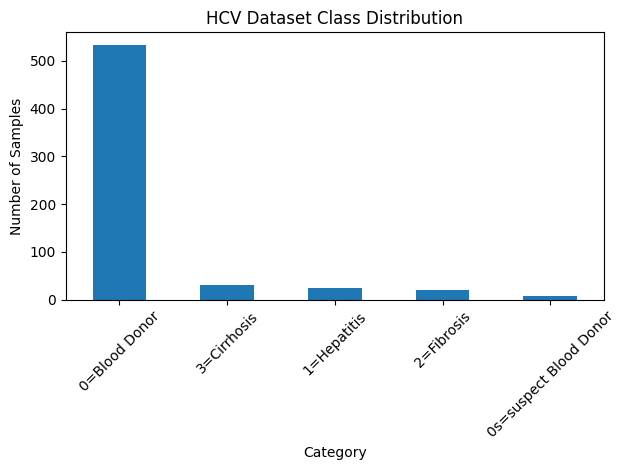

In [29]:
df["Category"].value_counts().plot(kind="bar")

plt.title("HCV Dataset Class Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Feature Analysis

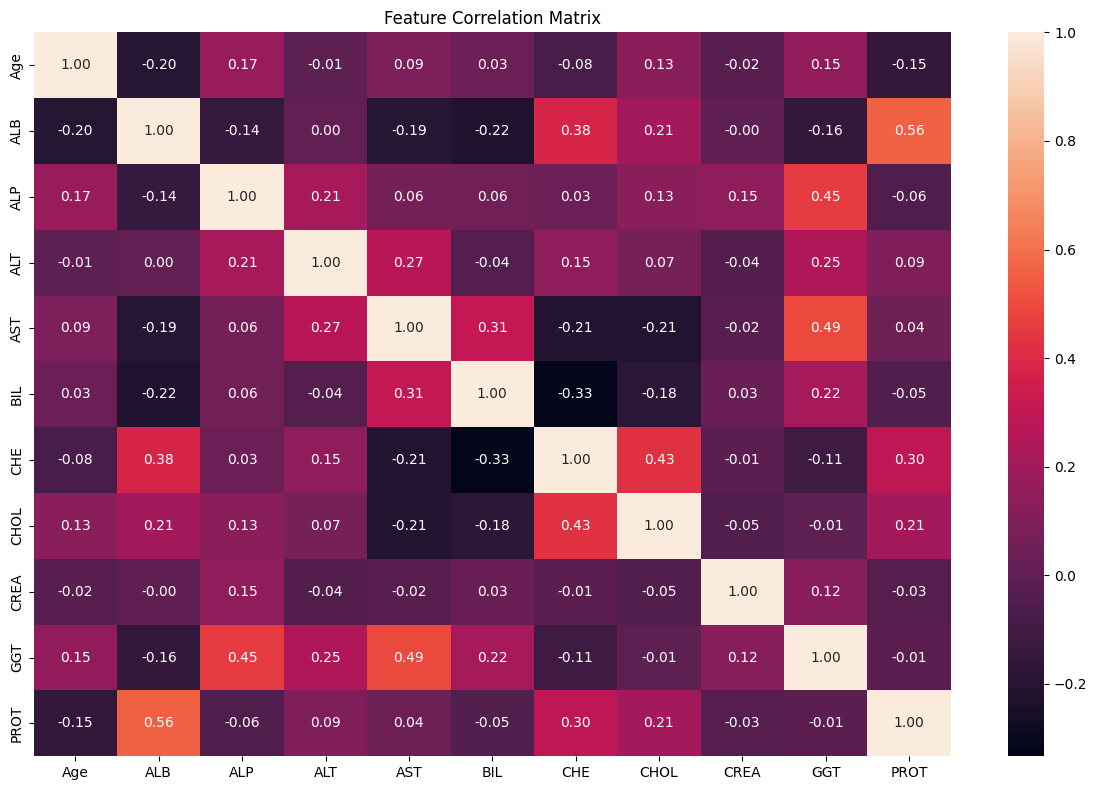

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation = df[numerical_features].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## Feature Distribution by HCV Category

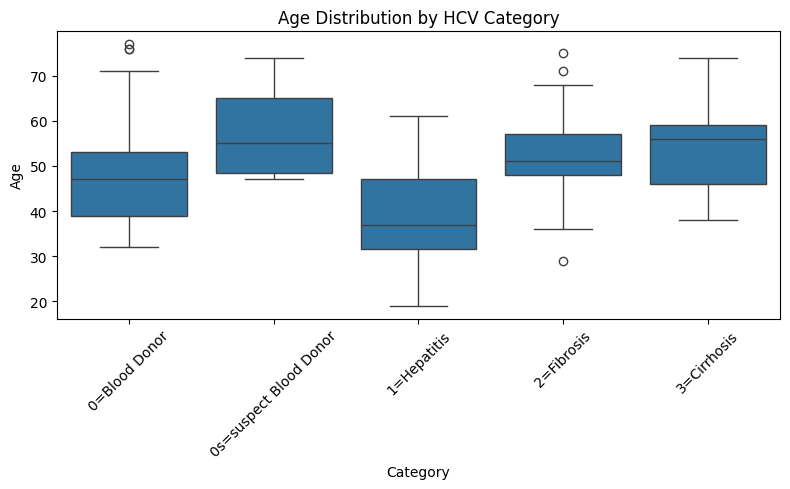

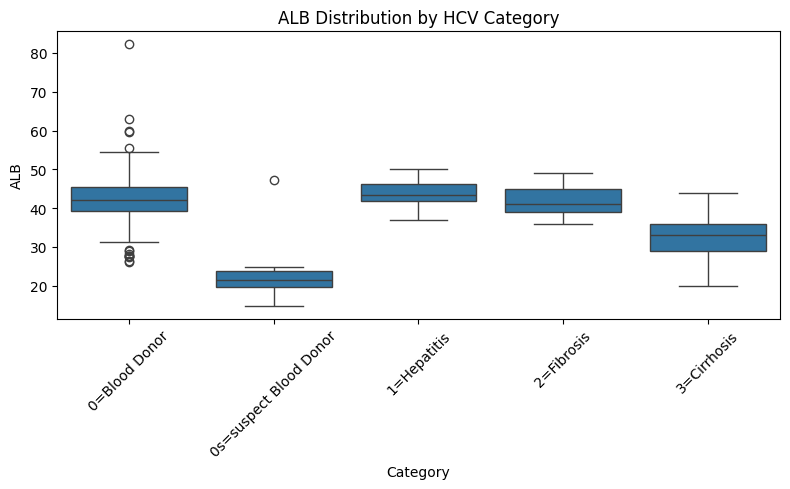

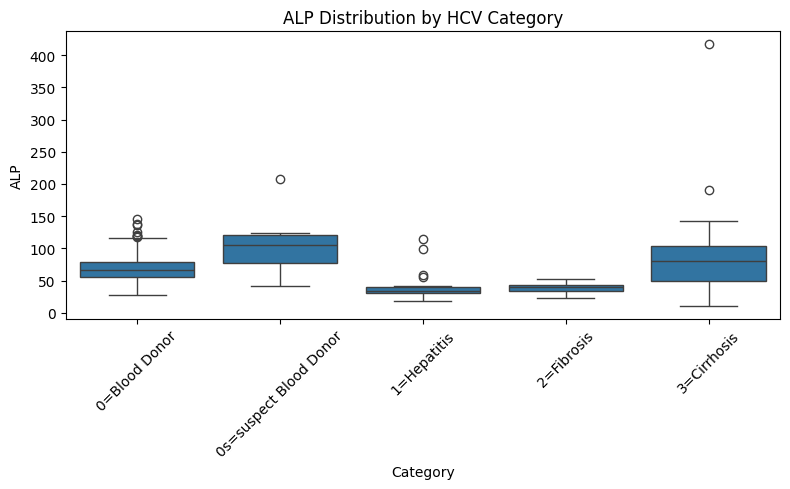

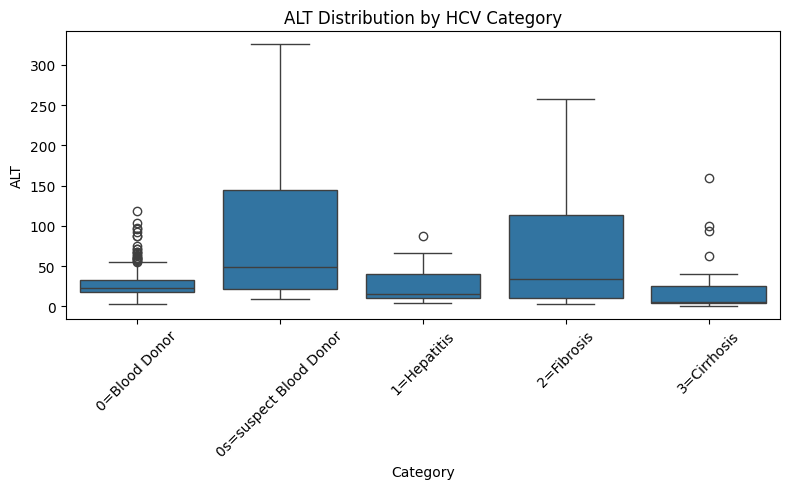

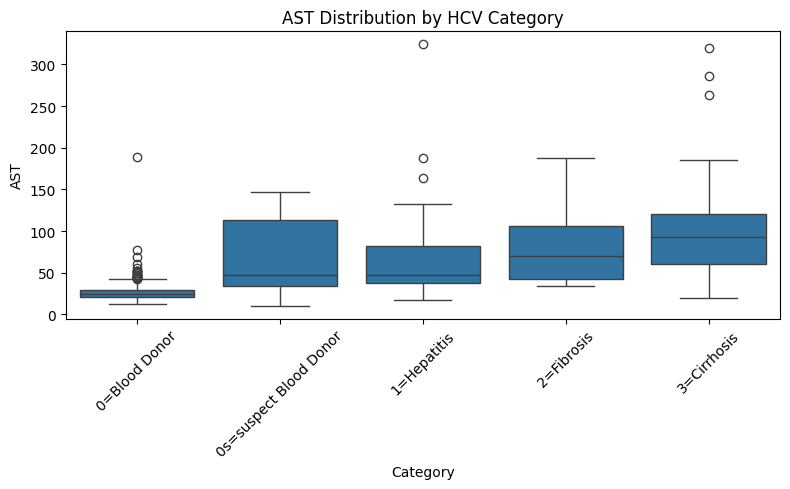

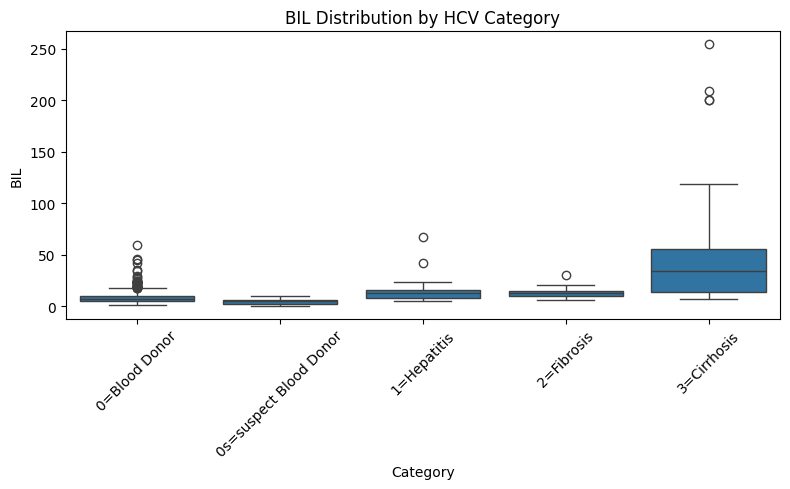

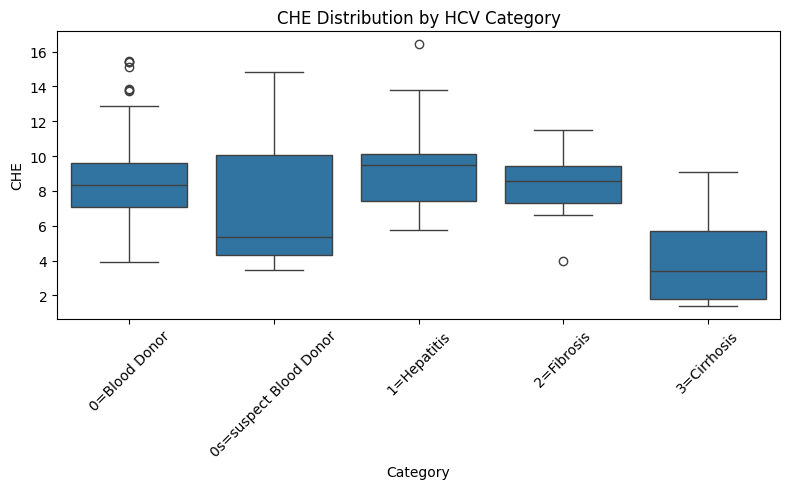

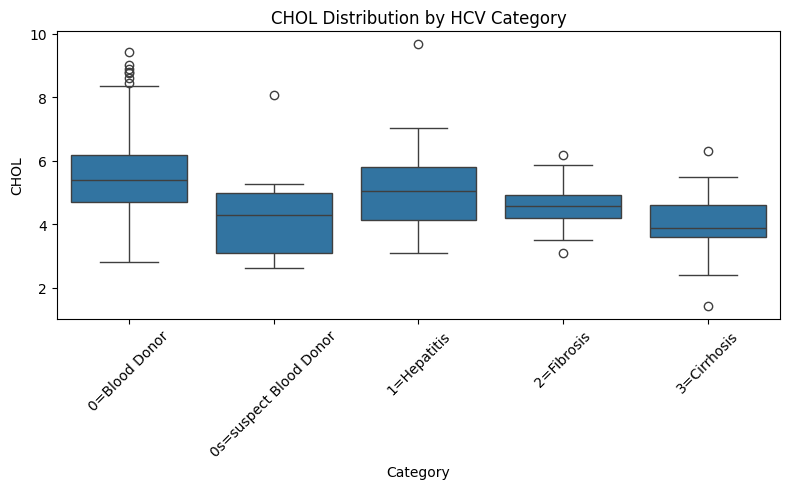

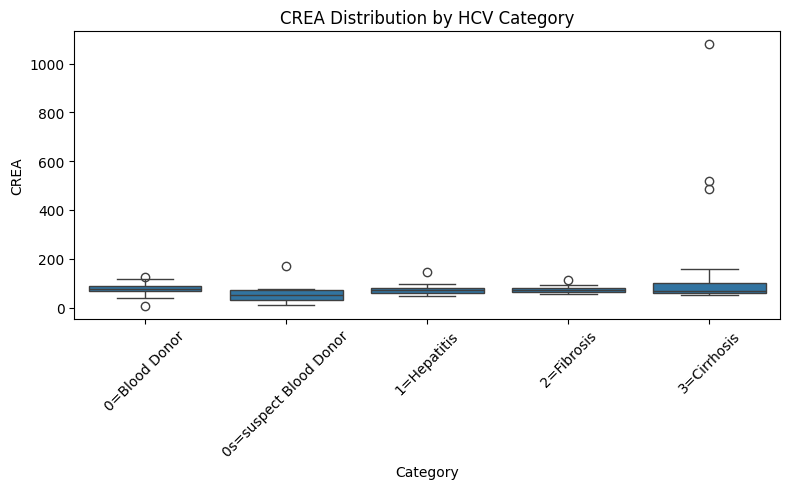

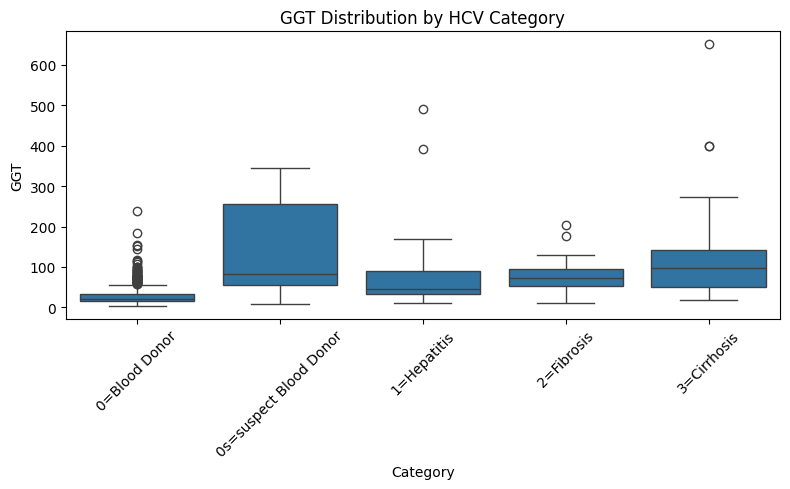

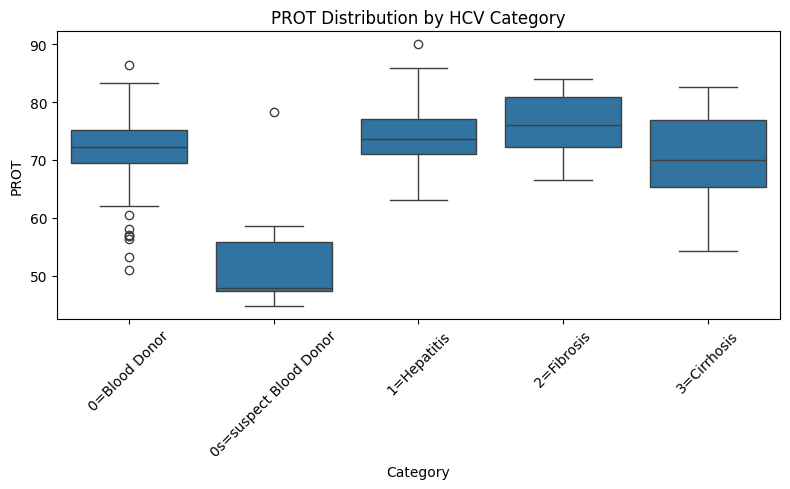

In [31]:
for feature in numerical_features:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="Category",
        y=feature
    )

    plt.title(f"{feature} Distribution by HCV Category")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Category-wise Feature Analysis

In [32]:
category_medians = (
    df.groupby("Category")[numerical_features]
    .median()
    .round(2)
)

category_medians

,Age,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
Category,,,,,,,,,,,
0=Blood Donor,47.0,42.2,66.70,23.10,24.8,6.9,8.35,5.40,78.00,21.40,72.20
0s=suspect Blood Donor,55.0,21.6,106.00,49.20,46.7,4.9,5.33,4.30,52.00,83.00,47.80
1=Hepatitis,37.0,43.5,34.60,15.20,47.2,13.0,9.51,5.06,72.25,45.55,73.65
2=Fibrosis,51.0,41.0,39.55,34.00,70.0,13.0,8.59,4.58,71.40,72.20,76.10
3=Cirrhosis,56.0,33.0,80.05,5.65,92.9,34.0,3.42,3.87,68.50,96.35,70.00


In [33]:
category_stats = (
    df.groupby("Category")[numerical_features]
    .agg(["mean", "median"])
    .round(2)
)

category_stats

Age           ALB            ALP             ALT  \
                         mean median   mean median    mean  median    mean   
Category                                                                     
0=Blood Donor           47.13   47.0  42.24   42.2   68.37   66.70   26.63   
0s=suspect Blood Donor  57.57   55.0  24.40   21.6  107.30  106.00  102.11   
1=Hepatitis             38.71   37.0  43.83   43.5   42.11   34.60   26.90   
2=Fibrosis              52.33   51.0  41.76   41.0   37.84   39.55   59.60   
3=Cirrhosis             53.47   56.0  32.48   33.0   93.22   80.05   22.97   

                                  AST           BIL          CHE         CHOL  \
                       median    mean median   mean median  mean median  mean   
Category                                                                        
0=Blood Donor           23.10   26.55   24.8   8.53    6.9  8.40   8.35  5.49   
0s=suspect Blood Donor  49.20   71.00   46.7   4.69    4.9  7.48   5.33  4.45   
1=Hepatitis             15.20   75.73   47.2  15.62   13.0  9.28   9.51  5.10   
2=Fibrosis              34.00   81.17   70.0  13.43   13.0  8.33   8.59  4.60   
3=Cirrhosis              5.65  107.46   92.9  59.13   34.0  3.82   3.42  4.01   

                                 CREA            GGT          PROT         
                       median    mean median    mean median   mean median  
Category                                                                   
0=Blood Donor            5.40   78.98  78.00   29.04  21.40  72.11  72.20  
0s=suspect Blood Donor   4.30   61.71  52.00  151.51  83.00  53.91  47.80  
1=Hepatitis              5.06   73.96  72.25   92.58  45.55  74.70  73.65  
2=Fibrosis               4.58   73.49  71.40   79.55  72.20  76.10  76.10  
3=Cirrhosis              3.87  138.22  68.50  129.44  96.35  70.05  70.00

## Statistical Feature Analysis — ANOVA

In [34]:
from scipy.stats import f_oneway

anova_results = []

for feature in numerical_features:
    groups = [
        group[feature].dropna().values
        for _, group in df.groupby("Category")
    ]

    f_stat, p_value = f_oneway(*groups)

    anova_results.append({
        "Feature": feature,
        "F-statistic": f_stat,
        "p-value": p_value
    })

anova_results = pd.DataFrame(anova_results)

anova_results = anova_results.sort_values("p-value")

anova_results

,Feature,F-statistic,p-value
4,AST,115.111305,4.262401e-73
5,BIL,68.399144,7.904114e-48
9,GGT,55.602426,5.485133e-40
1,ALB,46.832253,2.479755e-34
6,CHE,40.684701,3.090916e-30
10,PROT,29.851702,1.071373e-22
3,ALT,27.629757,4.224347e-21
2,ALP,21.437583,1.568500e-16
7,CHOL,17.191785,2.322628e-13
8,CREA,11.355392,6.790382e-09


## Feature Selection — Mutual Information

In [35]:
from sklearn.feature_selection import mutual_info_classif

X_mi = df[numerical_features].copy()
y_mi = df["Category"]

X_mi = X_mi.fillna(X_mi.median())

mi_scores = mutual_info_classif(
    X_mi,
    y_mi,
    random_state=42
)

mi_results = pd.DataFrame({
    "Feature": numerical_features,
    "Mutual Information": mi_scores
})

mi_results = mi_results.sort_values(
    "Mutual Information",
    ascending=False
)

mi_results

,Feature,Mutual Information
4,AST,0.226987
1,ALB,0.165942
2,ALP,0.155658
3,ALT,0.125107
5,BIL,0.120759
6,CHE,0.117203
9,GGT,0.108645
8,CREA,0.095393
10,PROT,0.073461
7,CHOL,0.062317


## Feature Importance — Random Forest

In [36]:
from sklearn.ensemble import RandomForestClassifier

X_rf = df[numerical_features].copy()
y_rf = df["Category"]

X_rf = X_rf.fillna(X_rf.median())

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_rf, y_rf)

rf_importance = pd.DataFrame({
    "Feature": numerical_features,
    "Importance": rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance

,Feature,Importance
4,AST,0.150065
1,ALB,0.127836
6,CHE,0.115043
10,PROT,0.103318
2,ALP,0.098255
5,BIL,0.095941
9,GGT,0.072593
3,ALT,0.071878
0,Age,0.065755
8,CREA,0.051315


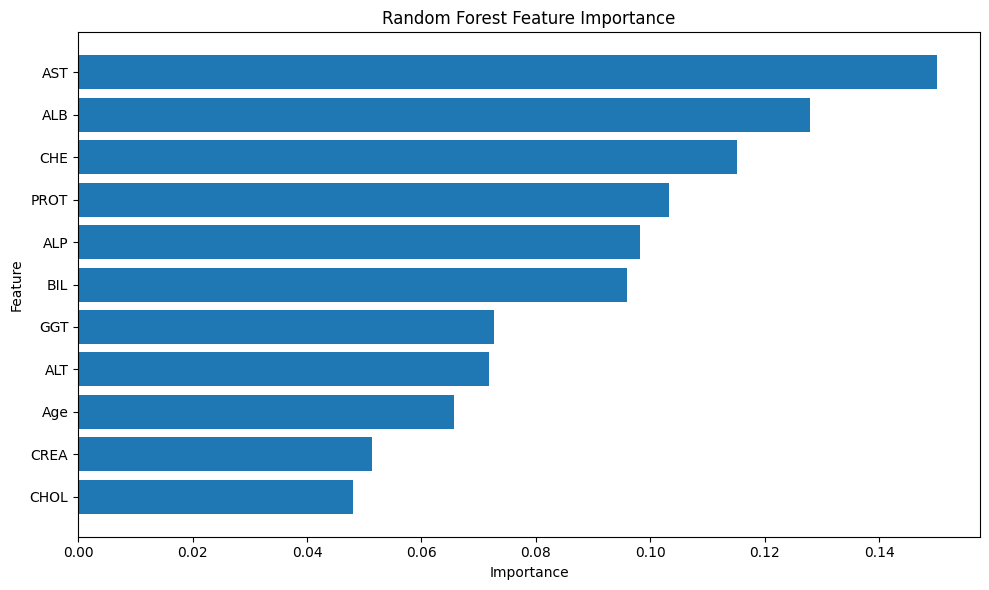

In [37]:
plt.figure(figsize=(10, 6))

plt.barh(
    rf_importance["Feature"],
    rf_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [38]:
anova_rank = anova_results[["Feature", "p-value"]].copy()

anova_rank["ANOVA Rank"] = (
    anova_rank["p-value"]
    .rank(method="min", ascending=True)
)

mi_rank = mi_results[["Feature", "Mutual Information"]].copy()

mi_rank["MI Rank"] = (
    mi_rank["Mutual Information"]
    .rank(method="min", ascending=False)
)

rf_rank = rf_importance[["Feature", "Importance"]].copy()

rf_rank["RF Rank"] = (
    rf_rank["Importance"]
    .rank(method="min", ascending=False)
)

In [39]:
feature_ranking = (
    anova_rank[["Feature", "p-value", "ANOVA Rank"]]
    .merge(
        mi_rank[["Feature", "Mutual Information", "MI Rank"]],
        on="Feature"
    )
    .merge(
        rf_rank[["Feature", "Importance", "RF Rank"]],
        on="Feature"
    )
)

feature_ranking["Average Rank"] = (
    feature_ranking[
        ["ANOVA Rank", "MI Rank", "RF Rank"]
    ].mean(axis=1)
)

feature_ranking = feature_ranking.sort_values(
    "Average Rank"
)

feature_ranking

,Feature,p-value,ANOVA Rank,Mutual Information,MI Rank,Importance,RF Rank,Average Rank
0,AST,4.262401e-73,1.0,0.226987,1.0,0.150065,1.0,1.000000
3,ALB,2.479755e-34,4.0,0.165942,2.0,0.127836,2.0,2.666667
1,BIL,7.904114e-48,2.0,0.120759,5.0,0.095941,6.0,4.333333
4,CHE,3.090916e-30,5.0,0.117203,6.0,0.115043,3.0,4.666667
7,ALP,1.568500e-16,8.0,0.155658,3.0,0.098255,5.0,5.333333
2,GGT,5.485133e-40,3.0,0.108645,7.0,0.072593,7.0,5.666667
5,PROT,1.071373e-22,6.0,0.073461,9.0,0.103318,4.0,6.333333
6,ALT,4.224347e-21,7.0,0.125107,4.0,0.071878,8.0,6.333333
9,CREA,6.790382e-09,10.0,0.095393,8.0,0.051315,10.0,9.333333
8,CHOL,2.322628e-13,9.0,0.062317,10.0,0.048000,11.0,10.000000


In [40]:
top_features = feature_ranking.head(8)["Feature"].tolist()

print("Preliminary top 8 features:")
print(top_features)

Preliminary top 8 features:
['AST', 'ALB', 'BIL', 'CHE', 'ALP', 'GGT', 'PROT', 'ALT']


In [41]:
candidate_features = {
    "all_features": numerical_features,
    "top_8": feature_ranking.head(8)["Feature"].tolist(),
    "top_6": feature_ranking.head(6)["Feature"].tolist(),
    "top_4": feature_ranking.head(4)["Feature"].tolist()
}

for name, features in candidate_features.items():
    print(f"\n{name}:")
    print(features)


all_features:
['Age', 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'GGT', 'PROT']

top_8:
['AST', 'ALB', 'BIL', 'CHE', 'ALP', 'GGT', 'PROT', 'ALT']

top_6:
['AST', 'ALB', 'BIL', 'CHE', 'ALP', 'GGT']

top_4:
['AST', 'ALB', 'BIL', 'CHE']


In [ ]:
from pathlib import Path

results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

feature_ranking.to_csv(
    results_dir / "feature_ranking.csv",
    index=False
)

print("Saved:", results_dir / "feature_ranking.csv")

Saved: ..\results\feature_ranking.csv


In [ ]:
print(feature_ranking)

   Feature       p-value  ANOVA Rank  Mutual Information  MI Rank  Importance  \
0      AST  4.262401e-73         1.0            0.226987      1.0    0.150065   
3      ALB  2.479755e-34         4.0            0.165942      2.0    0.127836   
1      BIL  7.904114e-48         2.0            0.120759      5.0    0.095941   
4      CHE  3.090916e-30         5.0            0.117203      6.0    0.115043   
7      ALP  1.568500e-16         8.0            0.155658      3.0    0.098255   
2      GGT  5.485133e-40         3.0            0.108645      7.0    0.072593   
5     PROT  1.071373e-22         6.0            0.073461      9.0    0.103318   
6      ALT  4.224347e-21         7.0            0.125107      4.0    0.071878   
9     CREA  6.790382e-09        10.0            0.095393      8.0    0.051315   
8     CHOL  2.322628e-13         9.0            0.062317     10.0    0.048000   
10     Age  1.190389e-08        11.0            0.045327     11.0    0.065755   

    RF Rank  Average Rank  

In [54]:
print("Preliminary feature ranking:")
display(feature_ranking)

print("\nCandidate feature sets:")
for name, features in candidate_features.items():
    print(f"{name}: {features}")

Preliminary feature ranking:


,Feature,p-value,ANOVA Rank,Mutual Information,MI Rank,Importance,RF Rank,Average Rank
0,AST,4.262401e-73,1.0,0.226987,1.0,0.150065,1.0,1.000000
3,ALB,2.479755e-34,4.0,0.165942,2.0,0.127836,2.0,2.666667
1,BIL,7.904114e-48,2.0,0.120759,5.0,0.095941,6.0,4.333333
4,CHE,3.090916e-30,5.0,0.117203,6.0,0.115043,3.0,4.666667
7,ALP,1.568500e-16,8.0,0.155658,3.0,0.098255,5.0,5.333333
2,GGT,5.485133e-40,3.0,0.108645,7.0,0.072593,7.0,5.666667
5,PROT,1.071373e-22,6.0,0.073461,9.0,0.103318,4.0,6.333333
6,ALT,4.224347e-21,7.0,0.125107,4.0,0.071878,8.0,6.333333
9,CREA,6.790382e-09,10.0,0.095393,8.0,0.051315,10.0,9.333333
8,CHOL,2.322628e-13,9.0,0.062317,10.0,0.048000,11.0,10.000000



Candidate feature sets:
all_features: ['Age', 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'GGT', 'PROT']
top_8: ['AST', 'ALB', 'BIL', 'CHE', 'ALP', 'GGT', 'PROT', 'ALT']
top_6: ['AST', 'ALB', 'BIL', 'CHE', 'ALP', 'GGT']
top_4: ['AST', 'ALB', 'BIL', 'CHE']
